# Lab 1: Customer Support Agent using Strands Agents

## Overview

In this lab, you'll create a **Customer Support Agent** using the Strands framework. This agent demonstrates the foundation for our complete AgentCore architecture with **five essential tools** - four simple tools and one that showcases Gateway + Lambda integration.

Your agent will include:
- **Tool 1**: `get_return_policy()` - Return policy lookup (simple)
- **Tool 2**: `calculate_shipping_cost()` - Shipping cost calculation (simple)
- **Tool 3**: `check_business_hours()` - Business hours information (simple)
- **Tool 4**: `get_contact_info()` - Department contact details (simple)

## Architecture Overview

Our customer support agent leverages the complete Amazon Bedrock AgentCore ecosystem in an integrated architecture:

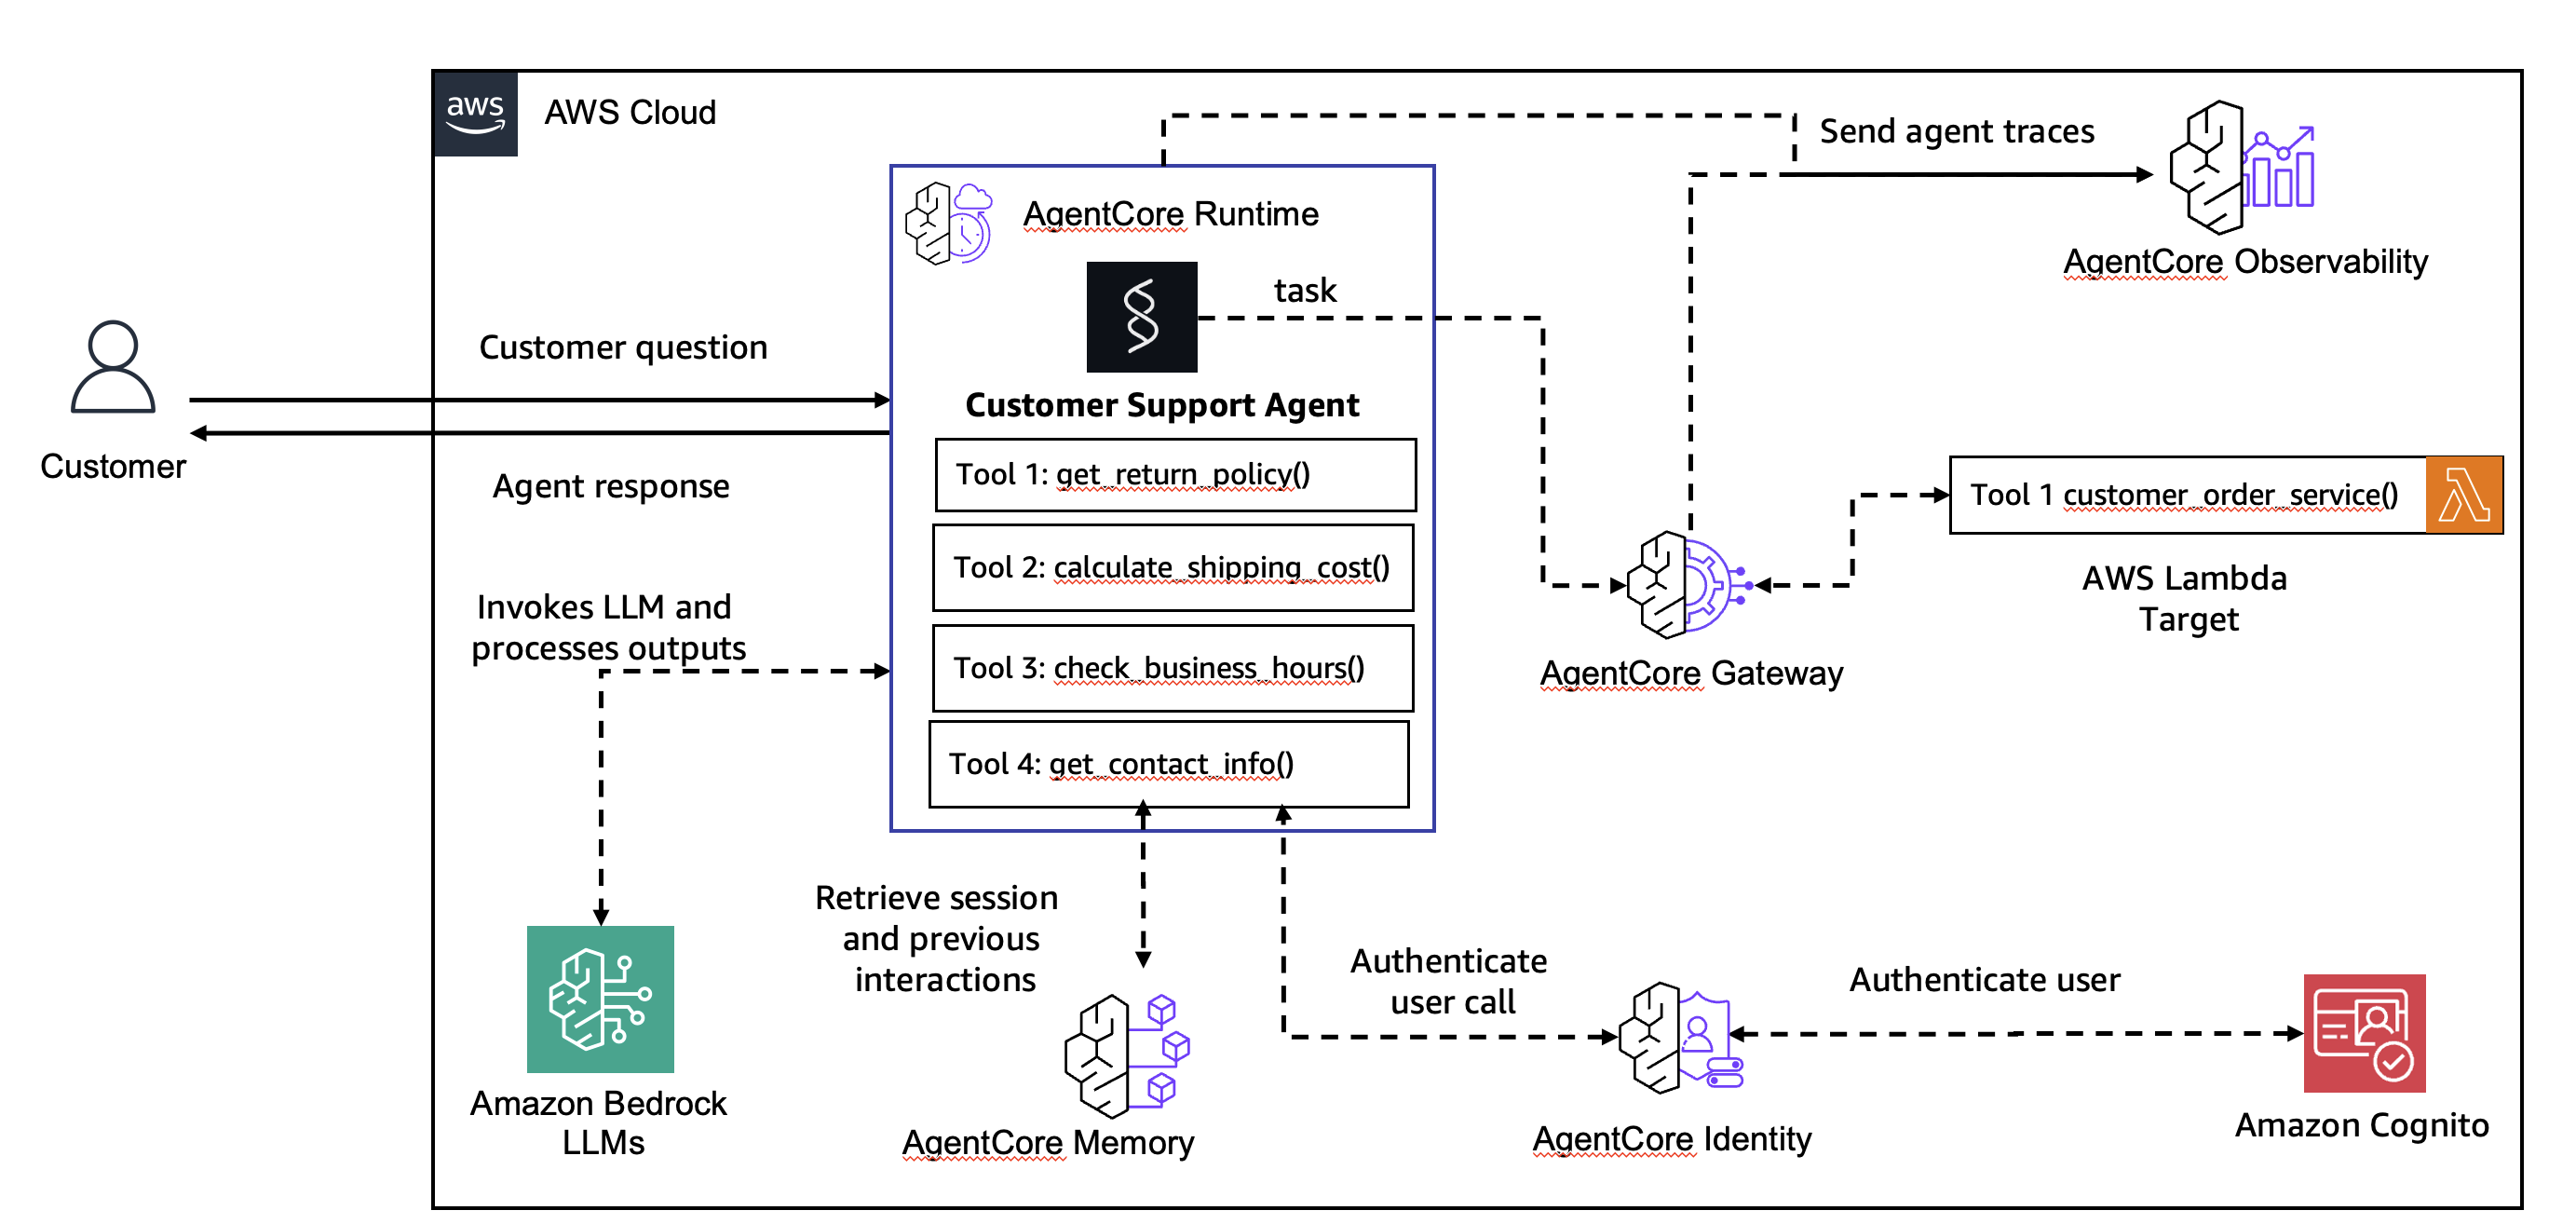

**Lab 1 Focus**: This lab establishes the foundation with:
- 🏗️ **AgentCore Runtime** (hosting the agent)
- 🤖 **Strands Agent** with 4 simple tools
- 🧠 **Foundation Model** (Claude 4.0 Sonnet)

**Future Labs**: AgentCore Memory, Gateway + Lambda, Identity, Observability

## Prerequisites

* Python 3.12+
* AWS credentials configured  
* Amazon Bedrock access
* Strands Agents and supporting libraries


## Step 1: Install Dependencies and Import Libraries

In [1]:
# Install required packages
%pip install strands-agents boto3 python-dotenv -q

# Import libraries
from strands import Agent
from strands.models import BedrockModel
from strands.tools import tool

print("Libraries imported successfully!")


Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


## Step 2: Create the Four Essential Tools

Based on our architecture diagram, we'll create **four simple tools** that work directly within the agent:

### Tool 1: Return Policy Tool

In [2]:
@tool
def get_return_policy(product_category: str) -> str:
    """Get return policy for a specific product category."""
    policies = {
        "electronics": "30-day return policy for electronics. Items must be in original packaging with all accessories. Restocking fee may apply.",
        "clothing": "60-day return policy for clothing. Items must have tags attached and be unworn.",
        "books": "Returns accepted within 30 days if in good condition.",
        "home": "45-day return policy for home goods. Large items may require special shipping.",
        "beauty": "30-day return policy for beauty products. Must be unopened for hygiene reasons."
    }
    
    policy = policies.get(product_category.lower())
    if policy:
        return f"Return Policy for {product_category.title()}: {policy}"
    else:
        return f"Standard 30-day return policy applies to {product_category}. Items must be in original condition."

print("Tool 1 (get_return_policy) created successfully!")


Tool 1 (get_return_policy) created successfully!


### Tool 2: Shipping Cost Calculator

In [3]:
@tool
def calculate_shipping_cost(weight_lbs: float, destination: str) -> str:
    """Calculate shipping cost based on weight and destination."""
    # Base shipping rates
    base_rates = {
        "domestic": 5.99,
        "canada": 12.99,
        "international": 19.99
    }
    
    # Weight-based pricing (per pound)
    weight_rates = {
        "domestic": 2.50,
        "canada": 4.00,
        "international": 6.50
    }
    
    # Normalize destination
    dest_key = "domestic"
    if "canada" in destination.lower():
        dest_key = "canada"
    elif any(country in destination.lower() for country in ["uk", "europe", "asia", "australia", "international"]):
        dest_key = "international"
    
    # Calculate total cost
    base_cost = base_rates[dest_key]
    weight_cost = weight_lbs * weight_rates[dest_key]
    total_cost = base_cost + weight_cost
    
    # Free shipping threshold
    if dest_key == "domestic" and total_cost > 50:
        return f"🎉 FREE SHIPPING to {destination}! (Order qualifies for free domestic shipping over $50)"
    
    return f"Shipping to {destination}: ${total_cost:.2f} (Base: ${base_cost}, Weight ({weight_lbs} lbs): ${weight_cost:.2f})"

print("Tool 2 (calculate_shipping_cost) created successfully!")


Tool 2 (calculate_shipping_cost) created successfully!


### Tool 3: Business Hours Information

In [4]:
@tool
def check_business_hours() -> str:
    """Get current business hours and availability information."""
    from datetime import datetime
    import pytz
    
    # Get current time in EST
    est = pytz.timezone('US/Eastern')
    current_time = datetime.now(est)
    current_hour = current_time.hour
    current_day = current_time.strftime('%A')
    
    # Business hours
    hours_info = """
 **TechCorp Customer Support Hours:**

**Monday - Friday:** 9:00 AM - 6:00 PM EST
**Saturday:** 10:00 AM - 4:00 PM EST  
**Sunday:** Closed

**24/7 Self-Service:** Available anytime at support.techcorp.com
**Emergency Support:** For urgent issues, call 1-800-TECH-911
    """
    
    # Check if currently open
    is_open = False
    if current_day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']:
        is_open = 9 <= current_hour < 18
    elif current_day == 'Saturday':
        is_open = 10 <= current_hour < 16
    
    status = "**CURRENTLY OPEN**" if is_open else "**CURRENTLY CLOSED**"
    
    return f"{status}\n\n{hours_info}\n\n*Current time: {current_time.strftime('%A, %B %d, %Y at %I:%M %p EST')}*"

print("Tool 3 (check_business_hours) created successfully!")


Tool 3 (check_business_hours) created successfully!


### Tool 4: Contact Information

In [5]:
@tool
def get_contact_info(department: str) -> str:
    """Get contact information for specific departments."""
    contacts = {
        "general": {
            "name": "General Support",
            "phone": "1-800-TECHCORP (1-800-832-4267)",
            "email": "support@techcorp.com",
            "hours": "Mon-Fri 9AM-6PM EST, Sat 10AM-4PM EST"
        },
        "technical": {
            "name": "Technical Support",
            "phone": "1-800-TECH-HELP (1-800-832-4435)",
            "email": "tech@techcorp.com", 
            "hours": "24/7 for Premium customers, Mon-Fri 9AM-6PM EST for Standard"
        },
        "billing": {
            "name": "Billing Department",
            "phone": "1-800-BILLING (1-800-245-5464)",
            "email": "billing@techcorp.com",
            "hours": "Mon-Fri 8AM-7PM EST"
        },
        "returns": {
            "name": "Returns & Exchanges",
            "phone": "1-800-RETURNS (1-800-738-8767)",
            "email": "returns@techcorp.com",
            "hours": "Mon-Fri 9AM-5PM EST"
        },
        "sales": {
            "name": "Sales Department", 
            "phone": "1-800-BUY-TECH (1-800-289-8324)",
            "email": "sales@techcorp.com",
            "hours": "Mon-Fri 8AM-8PM EST, Sat 9AM-5PM EST"
        }
    }
    
    dept_key = department.lower()
    if dept_key in contacts:
        contact = contacts[dept_key]
        return f"""
📞 **{contact['name']} Contact Information:**

**Phone:** {contact['phone']}
**Email:** {contact['email']}
**Hours:** {contact['hours']}

For fastest service, have your order number or customer ID ready when calling.
        """.strip()
    else:
        # Default to general support
        general = contacts['general']
        return f"""
I don't have specific contact info for '{department}', but here's our General Support:

📞 **General Support Contact Information:**

**Phone:** {general['phone']}
**Email:** {general['email']}
**Hours:** {general['hours']}

They can help you or transfer you to the right department.
        """.strip()

print("Tool 4 (get_contact_info) created successfully!")


Tool 4 (get_contact_info) created successfully!


## Step 3: Create and Configure the Customer Support Agent

In [6]:
# Initialize the Bedrock model (Claude 3.5 Sonnet)
model = BedrockModel(
    model_id="us.anthropic.claude-sonnet-4-20250514-v1:0",
    temperature=0.3,
    region_name="us-east-1"
)

# Create the customer support agent with all 5 tools
agent = Agent(
    model=model,
    tools=[
        get_return_policy,      # Tool 1: Simple policy lookup
        calculate_shipping_cost, # Tool 2: Simple cost calculation  
        check_business_hours,   # Tool 3: Simple hours info
        get_contact_info       # Tool 4: Simple contact lookup   
    ],
    system_prompt="""You are a helpful and professional customer support assistant for TechCorp. 

Your role is to:
- Provide accurate information using the tools available to you
- Be friendly, patient, and understanding with customers
- Always offer additional help after answering questions
- If you can't help with something, direct customers to the appropriate contact

You have access to 5 tools:
1. get_return_policy() - For return policy questions
2. calculate_shipping_cost() - For shipping cost estimates  
3. check_business_hours() - For support hours and availability
4. get_contact_info() - For department contact information

Always use the appropriate tool to get accurate, up-to-date information rather than guessing."""
)

print("Customer Support Agent created successfully!")
print("Agent configured with 4 tools and Claude 4.0 Sonnet model")


Customer Support Agent created successfully!
Agent configured with 4 tools and Claude 4.0 Sonnet model


## Step 4: Test the Customer Support Agent

Let's test our agent with sample queries to ensure all tools work correctly.

In [7]:
# Test 1: Return Policy Question
print("🧪 TEST 1: Return Policy Question")
print("=" * 50)
response = agent("What's the return policy for electronics?")
print(f"Customer: What's the return policy for electronics?")
print(f"Agent: {response.message['content'][0]['text']}")
print()

🧪 TEST 1: Return Policy Question
I'll look up the return policy for electronics for you.
Tool #1: get_return_policy
Here's the return policy for electronics:

**Electronics Return Policy:**
- **30-day return window** from the date of purchase
- Items must be returned in **original packaging** with all accessories included
- Please note that a **restocking fee may apply** depending on the item

To ensure a smooth return process, make sure to keep your receipt and all original packaging materials when you receive your electronics purchase.

Is there anything else you'd like to know about our return policy or do you need help with anything else?Customer: What's the return policy for electronics?
Agent: Here's the return policy for electronics:

**Electronics Return Policy:**
- **30-day return window** from the date of purchase
- Items must be returned in **original packaging** with all accessories included
- Please note that a **restocking fee may apply** depending on the item

To ensure 

In [8]:
# Test 2: Shipping Cost Question
print("🧪 TEST 2: Shipping Cost Question")
print("=" * 50)
response = agent("How much would shipping cost for a 5-pound package to Canada?")
print(f"Customer: How much would shipping cost for a 5-pound package to Canada?")
print(f"Agent: {response.message['content'][0]['text']}")
print()


🧪 TEST 2: Shipping Cost Question
I'll calculate the shipping cost for a 5-pound package to Canada for you.
Tool #2: calculate_shipping_cost
The shipping cost for a 5-pound package to Canada would be **$32.99**.

Here's the breakdown:
- Base shipping fee: $12.99
- Weight-based fee (5.0 lbs): $20.00
- **Total: $32.99**

Please note that this is an estimate and actual shipping costs may vary based on the specific destination within Canada and the shipping method selected at checkout.

Is there anything else I can help you with regarding shipping or any other questions?Customer: How much would shipping cost for a 5-pound package to Canada?
Agent: The shipping cost for a 5-pound package to Canada would be **$32.99**.

Here's the breakdown:
- Base shipping fee: $12.99
- Weight-based fee (5.0 lbs): $20.00
- **Total: $32.99**

Please note that this is an estimate and actual shipping costs may vary based on the specific destination within Canada and the shipping method selected at checkout.

Is

In [9]:
# Test 3: Business Hours Question
print("🧪 TEST 3: Business Hours Question")
print("=" * 50)
response = agent("Are you open right now? What are your business hours?")
print(f"Customer: Are you open right now? What are your business hours?")
print(f"Agent: {response.message['content'][0]['text']}")
print()

🧪 TEST 3: Business Hours Question
Let me check our current business hours and availability for you.
Tool #3: check_business_hours
Yes, we are **currently open**! 

Here are our business hours:

**TechCorp Customer Support Hours:**
- **Monday - Friday:** 9:00 AM - 6:00 PM EST
- **Saturday:** 10:00 AM - 4:00 PM EST
- **Sunday:** Closed

**Additional Support Options:**
- **24/7 Self-Service:** Available anytime at support.techcorp.com
- **Emergency Support:** For urgent issues, call 1-800-TECH-911

*Current time: Monday, August 04, 2025 at 10:44 AM EST*

Since we're open right now, I'm here to help with any questions or concerns you may have. Is there anything specific I can assist you with today?Customer: Are you open right now? What are your business hours?
Agent: Yes, we are **currently open**! 

Here are our business hours:

**TechCorp Customer Support Hours:**
- **Monday - Friday:** 9:00 AM - 6:00 PM EST
- **Saturday:** 10:00 AM - 4:00 PM EST
- **Sunday:** Closed

**Additional Suppor

In [11]:
# Test 4: Contact Information Question
print("🧪 TEST 4: Contact Information Question")
print("=" * 50)
response = agent("I need to speak to someone about billing. How can I contact them?")
print(f"Customer: I need to speak to someone about billing. How can I contact them?")
print(f"Agent: {response.message['content'][0]['text']}")
print()

🧪 TEST 4: Contact Information Question
I'll get you the contact information for our billing department.
Tool #4: get_contact_info
Here's how you can contact our billing department:

📞 **Billing Department Contact Information:**

**Phone:** 1-800-BILLING (1-800-245-5464)
**Email:** billing@techcorp.com
**Hours:** Monday-Friday 8AM-7PM EST

**Pro tip:** For the fastest service, have your order number or customer ID ready when you call.

Since it's currently Monday at 10:44 AM EST, the billing department is open right now, so you should be able to reach them immediately if you call.

Is there anything else I can help you with while you're here?Customer: I need to speak to someone about billing. How can I contact them?
Agent: Here's how you can contact our billing department:

📞 **Billing Department Contact Information:**

**Phone:** 1-800-BILLING (1-800-245-5464)
**Email:** billing@techcorp.com
**Hours:** Monday-Friday 8AM-7PM EST

**Pro tip:** For the fastest service, have your order num

## 🎉 Congratulations!

You've successfully created your first Strands agent! Here's what you accomplished:

### What You Built
- **4 Essential Tools** that handle common customer support tasks
- **Intelligent Agent** that automatically selects the right tool for each question
- **Professional Customer Service** with helpful responses and proper information

### Architecture Foundation
This agent represents the foundation layer of our complete AgentCore architecture:
- ✅ **Strands Agent** with tools (This Lab!)
- 🔄 **AgentCore Memory** (Coming in Lab 2)
- 🔄 **AgentCore Gateway + Lambda** (Coming in Lab 3) 
- 🔄 **AgentCore Identity** (Coming in Lab 4)
- 🔄 **AgentCore Observability** (Coming in Lab 5)
- 🔄 **AgentCore Runtime** (Coming in Lab 6)

### 🚀 Next Steps

**Lab 2**: Add memory to this agent so it can remember conversation context and customer preferences.

**Key Learning**: You now understand how to create tools, build agents, and test functionality locally - the foundation for all advanced AgentCore features!
